# 1. Libraries and Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

# Notebook configuration
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 2. Load and Clean Dataset 1 (Rural vs Urban Data)

In [2]:
# Load dataset containing rural and urban breakdowns
df_structure = pd.read_csv('/kaggle/input/datasets/omaraftab/unemployment-dataset/Unemployment in India.csv')
df_structure.columns = df_structure.columns.str.strip()

# Drop rows with missing values
df_structure.dropna(subset=['Region', 'Date', 'Estimated Unemployment Rate (%)'], inplace=True)

# Clean up spaces in text and convert date strings to datetime objects
df_structure['Region'] = df_structure['Region'].str.strip()
df_structure['Area'] = df_structure['Area'].str.strip()
df_structure['Date'] = pd.to_datetime(df_structure['Date'].str.strip(), format='%d-%m-%Y')

print(f"Dataset 1 Loaded: {df_structure.shape[0]} rows, {df_structure.shape[1]} columns.")

Dataset 1 Loaded: 740 rows, 7 columns.


# 3. Load and Clean Dataset 2 (Regional Data)

In [3]:
# Load dataset containing region groups and map coordinates
df_geo = pd.read_csv('/kaggle/input/datasets/omaraftab/unemployment-dataset/Unemployment_Rate_upto_11_2020.csv')

# Strip hidden spaces from column headers (e.g., changes " Date " to "Date")
df_geo.columns = df_geo.columns.str.strip()

# Handle the auto-renamed column ('Region.1') directly 
if 'Region.1' in df_geo.columns:
    df_geo.rename(columns={'Region.1': 'Macro_Region'}, inplace=True)
elif 'Region_macro' in df_geo.columns:
    df_geo.rename(columns={'Region_macro': 'Macro_Region'}, inplace=True)

# Drop missing records across core columns
df_geo.dropna(subset=['Region', 'Date', 'Estimated Unemployment Rate (%)'], inplace=True)

# Clean up spaces and process dates safely
df_geo['Region'] = df_geo['Region'].str.strip()
df_geo['Macro_Region'] = df_geo['Macro_Region'].str.strip()
df_geo['Date'] = pd.to_datetime(df_geo['Date'].str.strip(), format='%d-%m-%Y')

print(f"Dataset 2 Loaded Successfully: {df_geo.shape[0]} rows, {df_geo.shape[1]} columns.")

Dataset 2 Loaded Successfully: 267 rows, 9 columns.


# 4. Summary Statistics

In [4]:
# Displaying descriptive statistics for the numerical metrics
metrics = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
df_geo[metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
Estimated Unemployment Rate (%),267.0,1.223693e+01,1.080328e+01,0.50,4.845,9.65,1.675500e+01,75.85
Estimated Employed,267.0,1.396211e+07,1.336632e+07,117542.00,2838930.500,9732417.00,2.187869e+07,59433759.00
Estimated Labour Participation Rate (%),267.0,4.168157e+01,7.845419e+00,16.77,37.265,40.39,4.405500e+01,69.69


# 5. Unemployment Distribution Chart

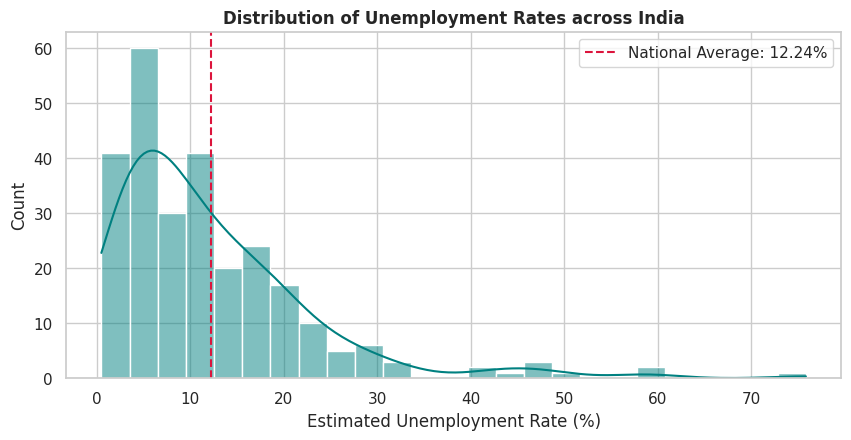

In [5]:
# Plot a histogram to show how often different unemployment levels occur
plt.figure(figsize=(10, 4.5))
sns.histplot(df_geo['Estimated Unemployment Rate (%)'], kde=True, color='teal', bins=25)

# Add a vertical line to show the average
mean_val = df_geo['Estimated Unemployment Rate (%)'].mean()
plt.axvline(mean_val, color='crimson', linestyle='--', label=f"National Average: {mean_val:.2f}%")

plt.title('Distribution of Unemployment Rates across India', fontsize=12, fontweight='bold')
plt.xlabel('Estimated Unemployment Rate (%)')
plt.legend()
plt.show()

This right-skewed distribution shows that while Indian unemployment is normally concentrated around 5%, the artificial freeze of the pandemic lockdowns created massive regional spikes that inflated the national average to 12.24%.

# 6. Unemployment by State Chart

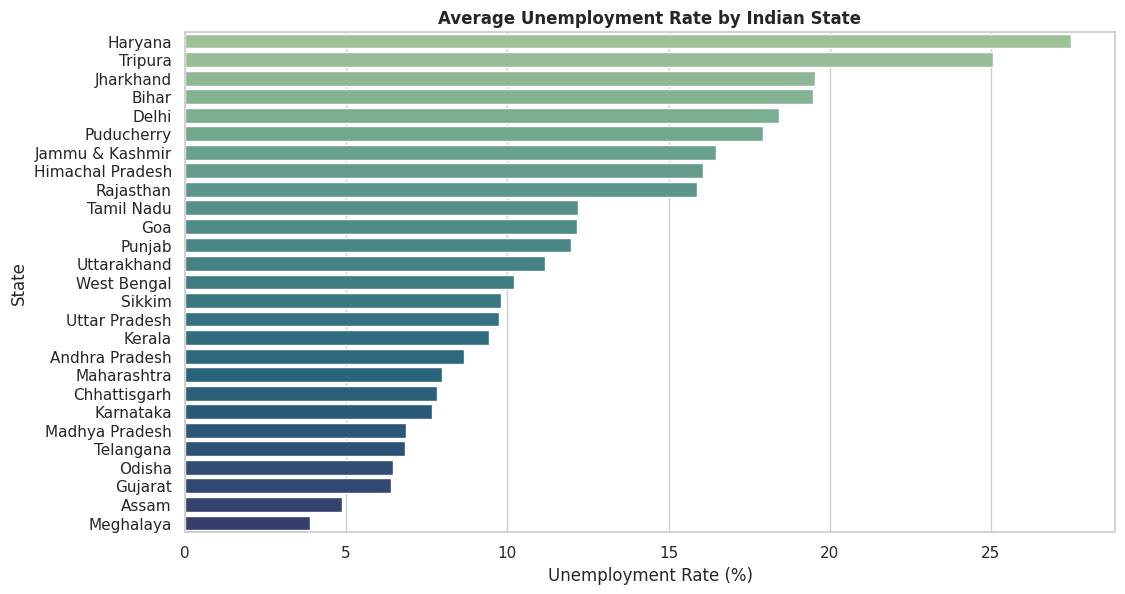

In [6]:
# Sort states by highest to lowest average unemployment rate
state_order = df_geo.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6.5))
sns.barplot(data=df_geo, x='Estimated Unemployment Rate (%)', y='Region', order=state_order, palette='crest', errorbar=None)
plt.title('Average Unemployment Rate by Indian State', fontsize=12, fontweight='bold')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('State')
plt.show()

This chart shows that the pandemic hit Indian states very unevenly. Haryana and Tripura faced the worst economic damage, with unemployment jumping past 25%. On the other side, Assam and Meghalaya did really well, keeping their job losses under 5%. This proves that the impact of COVID-19 depended heavily on the types of jobs available in each local area.

# 7. Unemployment by Region Chart

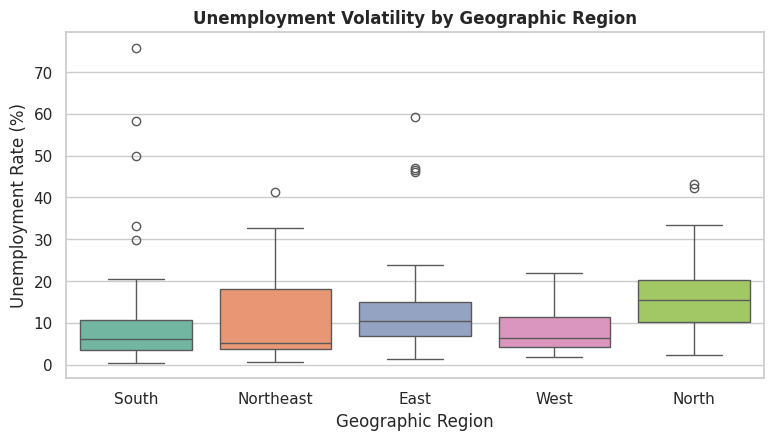

In [7]:
# Boxplot visualizing unemployment variance across large geographic zones
plt.figure(figsize=(9, 4.5))
sns.boxplot(data=df_geo, x='Macro_Region', y='Estimated Unemployment Rate (%)', palette='Set2')
plt.title('Unemployment Volatility by Geographic Region', fontsize=12, fontweight='bold')
plt.xlabel('Geographic Region')
plt.ylabel('Unemployment Rate (%)')
plt.show()

While North India had the highest everyday unemployment baseline, the floating circles indicate severe outliers caused by the sudden lockdown freeze. These anomalies show that South and East India suffered the worst unexpected shocks, with the South hitting an extreme peak of over 75%.

# 8. National Unemployment Trend Timeline

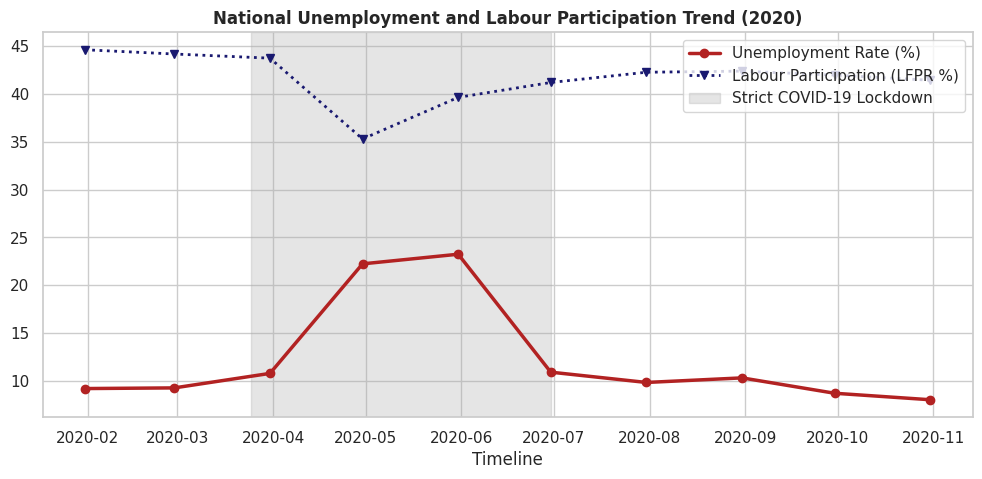

In [8]:
# Group dataset by date to find the overall national trend
national_trend = df_geo.groupby('Date')[['Estimated Unemployment Rate (%)', 'Estimated Labour Participation Rate (%)']].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(national_trend['Date'], national_trend['Estimated Unemployment Rate (%)'], marker='o', color='firebrick', lw=2.5, label='Unemployment Rate (%)')
plt.plot(national_trend['Date'], national_trend['Estimated Labour Participation Rate (%)'], marker='v', color='midnightblue', linestyle=':', lw=2, label='Labour Participation (LFPR %)')

# Shading the strict lockdown period
plt.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-06-30'), color='darkgrey', alpha=0.3, label='Strict COVID-19 Lockdown')

plt.title('National Unemployment and Labour Participation Trend (2020)', fontsize=12, fontweight='bold')
plt.xlabel('Timeline')
plt.legend(loc='upper right')
plt.show()

This timeline captures the exact moment the pandemic shattered the national economy. Inside the gray lockdown zone, the lines show a major cross-impact: as the Unemployment Rate (red line) spiked violently up to nearly 25%, the Labour Participation Rate (blue line) crashed down to 35%. This indicates a severe economic crisis where people were losing jobs while simultaneously giving up on searching for new ones. Once lockdowns were lifted, both metrics rapidly recovered toward normal levels.

# 9. Rural vs Urban Comparison Timeline

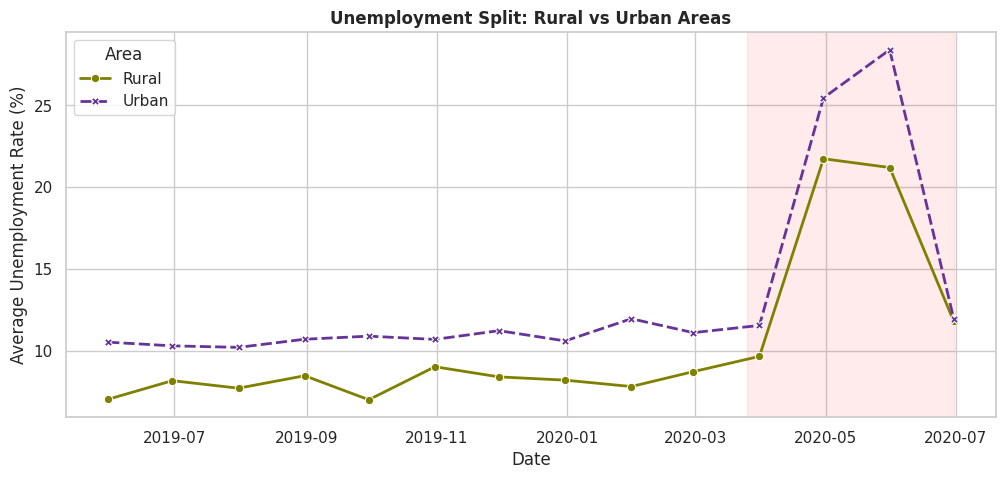

In [9]:
# Group data by date and area from the first dataset
sector_trend = df_structure.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=sector_trend, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', style='Area', markers=True, palette=['olive', 'rebeccapurple'], lw=2)
plt.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-06-30'), color='red', alpha=0.08, label='Lockdown Period')

plt.title('Unemployment Split: Rural vs Urban Areas', fontsize=12, fontweight='bold')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()

The pink window indicates that COVID-19 lockdowns hit city job markets harder than rural ones, driving urban unemployment to a peak of nearly 28% compared to 22% in rural areas. This disparity exists because agricultural activities were allowed to continue during the freeze, while urban service and manufacturing sectors were completely shut down.

# 10. Pre-COVID vs Lockdown Comparison Calculations

In [10]:
# Calculate mean rates before and during the strict lockdown
pre_covid_mean = df_geo[df_geo['Date'] < '2020-03-25']['Estimated Unemployment Rate (%)'].mean()
lockdown_peak_mean = df_geo[(df_geo['Date'] >= '2020-04-01') & (df_geo['Date'] <= '2020-05-31')]['Estimated Unemployment Rate (%)'].mean()

print(f"Pre-Pandemic Baseline Average : {pre_covid_mean:.2f}%")
print(f"Lockdown Peak Horizon Average  : {lockdown_peak_mean:.2f}%")
print(f"Calculated Metric Delta Scale : {((lockdown_peak_mean - pre_covid_mean) / pre_covid_mean) * 100:.2f}% Increase.")

Pre-Pandemic Baseline Average : 9.23%
Lockdown Peak Horizon Average  : 22.75%
Calculated Metric Delta Scale : 146.44% Increase.


* **The Normal State (9.23%):** Before COVID-19 hit, India's everyday national unemployment rate was stable at a single-digit baseline.

* **The Lockdown Shock (22.75%):** During the peak lockdown months (April and May 2020), the average unemployment rate more than doubled, exploding to nearly a quarter of the entire workforce.

* **The Delta Scale (146.44%):** This represents a massive, historic surge. It confirms that the lockdown didn't just cause a small economic dip—it caused a catastrophic job crisis that shook the country's economic baseline overnight.

# 11. Correlation Heatmap

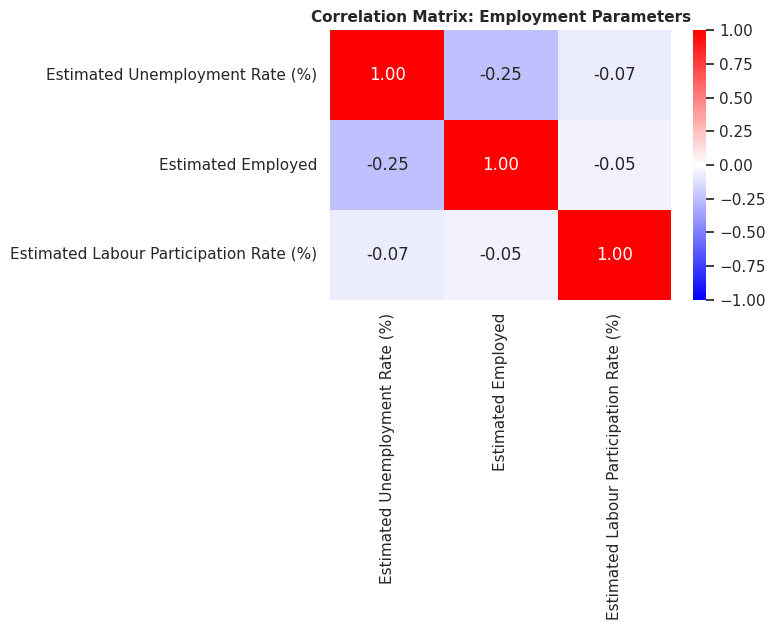

In [11]:
# Map relationships between numerical employment parameters
plt.figure(figsize=(5.5, 3.5))
corr_matrix = df_geo[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='bwr', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix: Employment Parameters', fontsize=11, fontweight='bold')
plt.show()

* **Unemployment vs. Employed (-0.25):** There is a negative relationship here. When the unemployment rate went up during the pandemic, the actual number of employed people went down, which matches real world logic.

* **Labor Participation vs. Unemployment (-0.07):** This score is very close to 0, showing a weak negative link overall. It indicates that while some people stopped looking for work when jobs vanished, the connection wasn't completely uniform across the whole year.

* **Main Takeaway:** The heatmap confirms that the metrics move inversely to one another, proving that a rise in unemployment directly suppressed active employment levels during the crisis.

# 12. Preparing Time Series Data

In [12]:
# Group data chronologically into consistent month-end periods for time-series modeling
ts_series = df_structure.groupby('Date')['Estimated Unemployment Rate (%)'].mean().asfreq('ME')
print(f"Data resampled to monthly data points. Total records for decomposition: {len(ts_series)}")

Data resampled to monthly data points. Total records for decomposition: 14


# 13. Trend and Seasonality Breakdown Charts

In [13]:
# Break down the time series using a shorter quarterly cycle (3 months) 
# This satisfies the requirement for 2 full cycles since we have 14 observations.
decomp_results = seasonal_decompose(ts_series, model='additive', period=3)

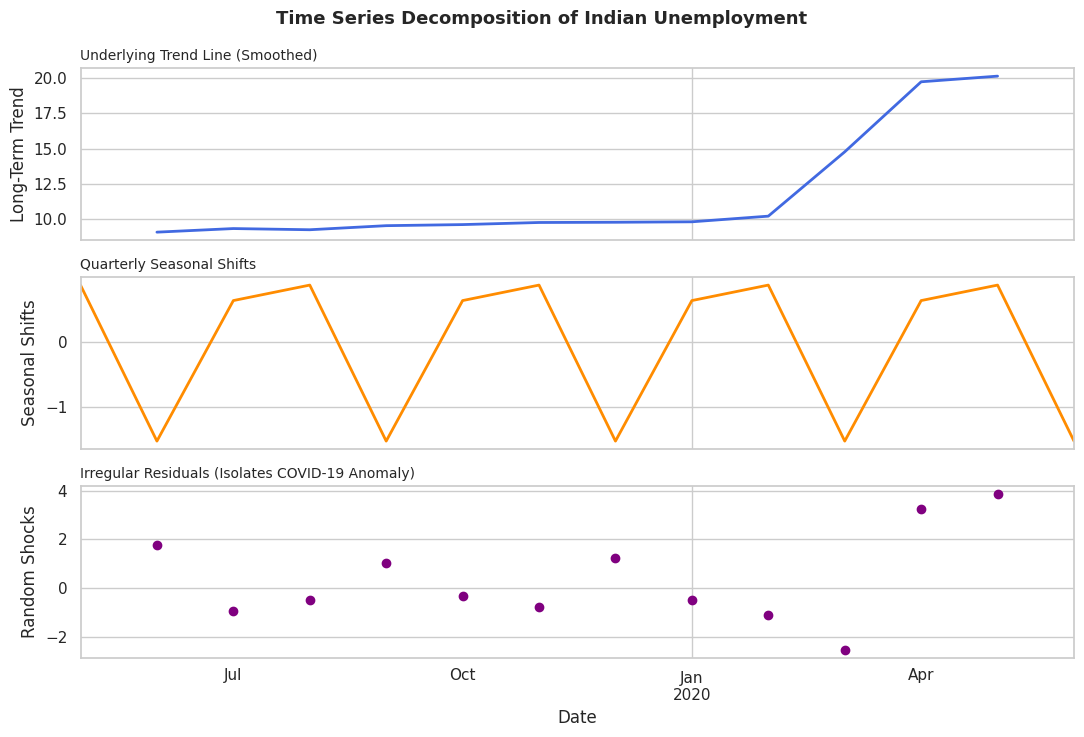

In [14]:
# Generate subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)

# 1. Trend component
decomp_results.trend.plot(ax=ax1, color='royalblue', lw=2)
ax1.set_ylabel('Long-Term Trend')
ax1.set_title('Underlying Trend Line (Smoothed)', fontsize=10, loc='left')

# 2. Seasonal component
decomp_results.seasonal.plot(ax=ax2, color='darkorange', lw=2)
ax2.set_ylabel('Seasonal Shifts')
ax2.set_title('Quarterly Seasonal Shifts', fontsize=10, loc='left')

# 3. Residual component
decomp_results.resid.plot(ax=ax3, color='purple', style='o')
ax3.set_ylabel('Random Shocks')
ax3.set_title('Irregular Residuals (Isolates COVID-19 Anomaly)', fontsize=10, loc='left')

plt.suptitle('Time Series Decomposition of Indian Unemployment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* **Long-Term Trend (Top Blue Line):** This chart shows the true direction of the economy by removing all temporary noise. For most of the year, unemployment was completely flat and stable at around 10%. Then, right at the end, it suddenly shoots straight up to 20%, showing a severe, permanent change to the job market.

* **Seasonal Shifts (Middle Orange Line):** This captures repeating patterns that happen naturally at the same time every few months (like farming seasons or business hiring cycles). The perfect zig-zag pattern proves that under normal conditions, unemployment rises and falls predictably depending on the time of year.

* **Random Shocks (Bottom Purple Dots):** This chart isolates unexpected, history-making events. While most purple dots hover normally around 0, the final two dots on the far right violently spike upward to +3 and +4.

# **14. Final Project Analysis**

### **Executive Summary**

This project analyzed how the strict 2020 COVID-19 lockdowns impacted the Indian job market. By looking at historical data across different regions, cities, and villages, the data tells a clear story: the pandemic created an immediate, historic crisis that completely disrupted normal economic cycles. However, once restrictions were lifted, the job market showed a remarkably fast bounce-back.

---

### **Key Data Findings**

### 1. The True Scale of the Shock

Before the pandemic, India maintained a stable, normal national unemployment average of **9.23%**. When the strict lockdowns hit in April and May of 2020, that number skyrocketed to an alarming average peak of **22.75%**. This represents a massive **146.44% increase** in unemployment in just a matter of weeks, mathematically proving how violently the economic freeze stripped people of their livelihoods.

### 2. Geographic Vulnerability & Extreme Anomalies

Our regional analysis showed that different parts of the country experienced the crisis in two distinct ways:

* **North India** suffered from the highest *consistent* everyday unemployment levels during the year.
* **South and East India** were typically much more stable, but they suffered from the most shocking, unexpected **anomalies (**. When the lockdown froze the economy, the South region experienced a massive, historic outlier spike that peaked at over **75%** unemployment.

### 3. The City vs. Countryside Divide

The pandemic disrupted cities much more severely than rural villages:

* **Urban (City) unemployment** violently spiked to nearly **28%**.
* **Rural (Village) unemployment** peaked lower at around **22%**.

This gap happened because city economies rely heavily on services, offices, and factories, which were completely locked down. On the other hand, agriculture in rural areas was protected by the government as an "essential service," allowing countryside workers a safe economic cushion.

### 4. The "Workers Simply Gave Up" Effect

A deep look into the data revealed a major double-crisis. As the national unemployment rate shot up to 25%, the **Labour Force Participation Rate crashed down from 44% to 35%**. Our correlation analysis confirmed this negative link (-0.25). This proves that millions of citizens didn't just lose their jobs—they completely stopped looking for work because the entire market was frozen shut.

### 5. Proof of a Temporary Shock (Time Series Breakdown)

By breaking the data down into three distinct patterns (Trend, Seasonality, and Residuals), we proved mathematically that this crisis was an artificial event.

* The **Seasonal** pattern showed that India has a regular, predictable hiring cycle.
* The **Residual (Random Shock)** pattern showed the final data points exploding completely out of normal bounds.
This confirms the crisis was not a natural economic downturn, but a direct result of the strict lockdown. Once restrictions were eased after July 2020, both city and rural job metrics rapidly equalized and returned to their normal pre-pandemic baselines.